In [24]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [ ]:
from src.config import *
from src.utils import set_seed
from src.data_loader import load_dataset
from src.preprocessing import preprocess_pipeline
from src.model_tabnet import (
    train_pipeline,
    predict,
    load_saved_model
)
from src.evaluation import regression_metrics

from src.visualization import (
    plot_prediction,
    plot_residual
)

In [16]:
df = load_dataset()

df.head()

[2026-07-04 19:23:22] Loading dataset : C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\dataset\heartv1.csv
[2026-07-04 19:23:22] Dataset loaded successfully.


,sex,age,cp,resting_BP,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Max Heart Rate Reserve,Heart Disease Risk Score,target
0,male,65,0,130,254,0,0,147,0,1.4,1,1,3,10,11.44,0
1,male,53,0,140,261,0,0,186,1,0.0,2,0,2,-17,13.51,1
2,male,50,0,122,222,0,0,186,0,0.0,2,0,2,-14,9.46,1
3,female,47,1,112,160,0,1,138,0,0.0,1,0,2,37,8.34,1
4,male,47,0,142,309,0,0,147,1,0.0,1,3,3,28,13.43,0


In [17]:
data = preprocess_pipeline(df)

[2026-07-04 19:23:22] ============================================================
[2026-07-04 19:23:22] START PREPROCESSING
[2026-07-04 19:23:22] ============================================================
[2026-07-04 19:23:22] Duplicate removed : 723
[2026-07-04 19:23:22] Current rows      : 312
[2026-07-04 19:23:22] Missing values : 0
[2026-07-04 19:23:22] Rows removed : 0
[2026-07-04 19:23:22] Categorical features encoded.
[2026-07-04 19:23:22] Feature shape : (312, 14)
[2026-07-04 19:23:22] Target shape  : (312,)
[2026-07-04 19:23:22] Feature columns saved.
[2026-07-04 19:23:22] Dataset split completed.
[2026-07-04 19:23:22] Train      : 218
[2026-07-04 19:23:22] Validation : 47
[2026-07-04 19:23:22] Test       : 47
[2026-07-04 19:23:22] Scaler saved successfully.
[2026-07-04 19:23:22] Processed datasets saved successfully.
[2026-07-04 19:23:22] ============================================================
[2026-07-04 19:23:22] PREPROCESSING FINISHED
[2026-07-04 19:23:22] ========

In [18]:
model, history = train_pipeline(
    data["X_train"],
    data["y_train"],
    data["X_valid"],
    data["y_valid"]
)

[2026-07-04 19:23:22] ============================================================
[2026-07-04 19:23:22] START TABNET TRAINING
[2026-07-04 19:23:22] ============================================================
[2026-07-04 19:23:22] TabNet model created.
[2026-07-04 19:23:22] Starting TabNet training...
epoch 0  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 1  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 2  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 3  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 4  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 5  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 6  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 7  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 8  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 9  | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 10 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 11 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 12 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 13 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 14 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 15 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 16 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 17 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 18 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 19 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s
epoch 20 | loss: 0.0     | val_0_mse: 230.17229|  0:00:00s

Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_mse = 230.17229
[2026-07-04 19:23:23] Training completed.
Successfully saved model at C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\models\tabnet_model.zip
[202

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [19]:
prediction = predict(
    model,
    data["X_test"]
)

prediction[:10]

array([  0.8955145, -11.61289  ,   2.0544758,  -6.783962 ,  -0.50634  ,
        -3.1085906,   5.644501 ,  -8.049446 ,   5.357709 ,  11.529327 ],
      dtype=float32)

In [20]:
metrics = regression_metrics(
    data["y_test"],
    prediction
)

metrics

[2026-07-04 19:23:23] Evaluation completed.


,MAE,RMSE,MAPE,R2
MLP,11.108101,13.154308,93.208837,-31.309946


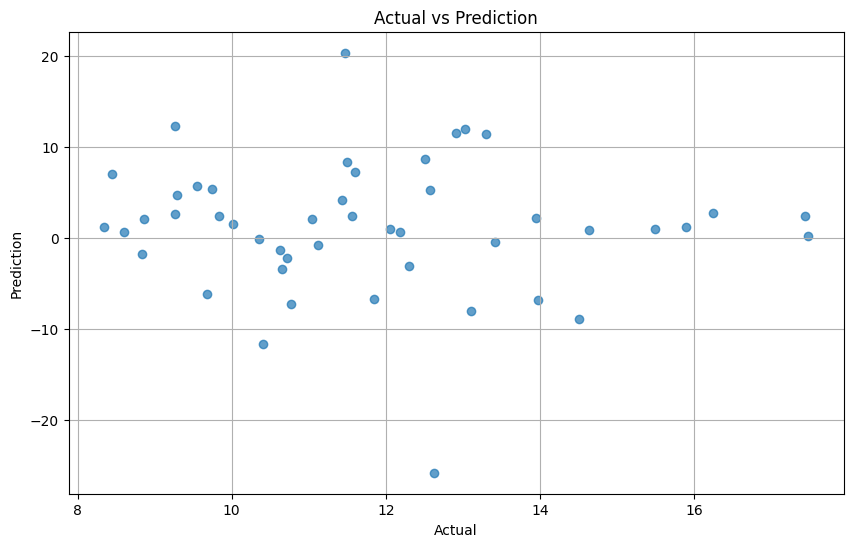

In [21]:
plot_prediction(
    data["y_test"],
    prediction
)

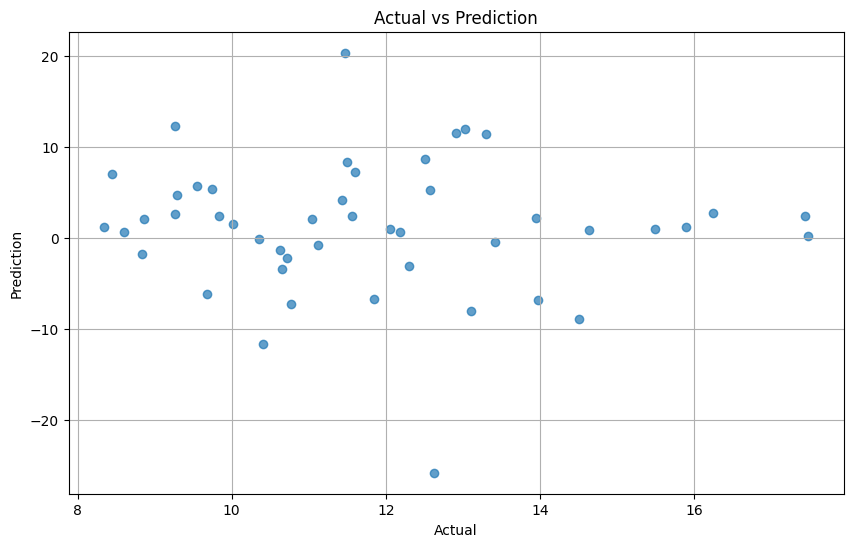

In [22]:
plot_prediction(
    data["y_test"],
    prediction
)

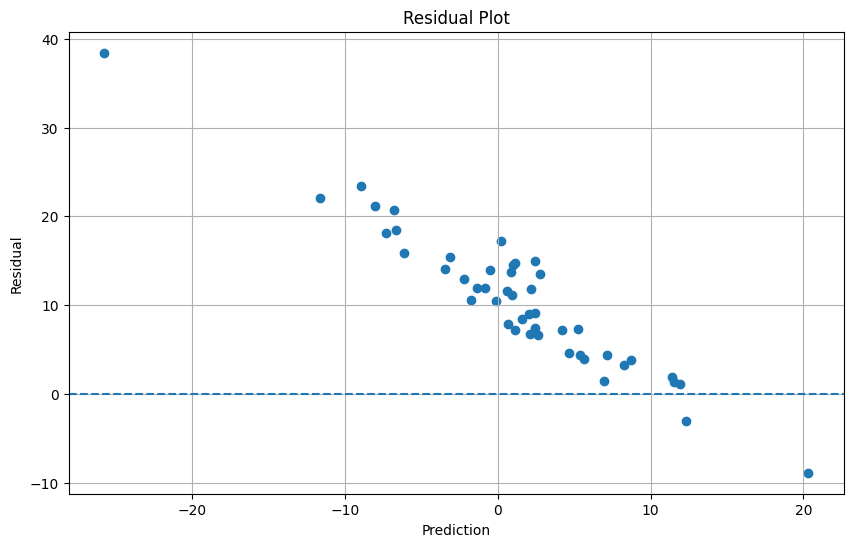

In [23]:
plot_residual(
    data["y_test"],
    prediction
)